# Plane Wave Ultrasound Imaging via Stolt's f-k Migration

This notebook walks through the full pipeline for reconstructing focused ultrasound B-mode images from multi-angle plane-wave RF data using Stolt's frequency–wavenumber (f-k) migration algorithm.

**What you will see:**
1. The physics behind plane-wave ultrafast imaging and the exploding reflector model
2. How the Stolt f-k algorithm maps unfocused RF data to focused images
3. Before/after visualizations: raw RF arcs → sharp point-spread functions
4. Coherent angle compounding with 7 steered angles (−1.5° to +1.5°)
5. Quantitative metrics: lateral FWHM and cyst CNR

**Precomputed results** are loaded from `evaluation/reference_outputs/` so this notebook runs in seconds.

In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
%matplotlib inline

# Resolve paths relative to this notebook
TASK_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, TASK_DIR)
REF_DIR  = os.path.join(TASK_DIR, 'evaluation', 'reference_outputs')
DATA_DIR = os.path.join(TASK_DIR, 'data')

print('Task directory:', TASK_DIR)

Task directory: /home/pisquare/zhijun/imaging-101/tasks/plane_wave_ultrasound


## 1. Physics Background

### From focused beams to plane waves

Conventional ultrasound fires a tightly focused beam and moves it laterally, acquiring one A-line per transmit event. For a 128-element array at 20 MHz, this gives ~50 frames/s. **Ultrafast imaging** replaces the focused beam with a single unfocused plane wave that insonifies the entire medium simultaneously, achieving >1000 frames/s.

The trade-off: a single plane wave produces a low-contrast B-mode image. High quality requires **coherent compounding** — transmitting plane waves at several slightly different steering angles and coherently averaging the focused images. With 7 angles spanning ±1.5°, image quality matches focused-beam imaging.

### The Exploding Reflector Model (ERM)

The standard reconstruction method is delay-and-sum (DAS) beamforming, which is O(N²). The **Stolt f-k migration** algorithm reduces this to O(N log N) by working in the frequency–wavenumber domain.

The key insight is the **Exploding Reflector Model**: instead of tracing round-trip paths (transmit + receive), we imagine that all scatterers simultaneously "explode" at t = 0 and emit waves that propagate **upward** toward the transducer at an *effective velocity*:

$$v = \frac{c}{\sqrt{1 + \cos\theta + \sin^2\theta}}$$

where θ is the steering angle and c = 1540 m/s is the speed of sound. For θ = 0 (straight-on plane wave), v = c/√2 ≈ 1089 m/s — exactly half the round-trip velocity, as expected for a two-way to one-way conversion.

### Stolt's frequency mapping

Under the ERM, the recorded 2D wavefield P(t, x) has a dispersion relation in the (f, k_x) domain:

$$k_z = \frac{1}{v}\sqrt{\left(\frac{2\pi f}{v}\right)^2 - k_x^2}$$

Migration = remapping the temporal frequency f to the migrated axial frequency:

$$f_{kz} = v\sqrt{k_x^2 + \frac{4 f^2}{\beta^2 c^2}}$$

where $\beta = (1+\cos\theta)^{1.5} / (1 + \cos\theta + \sin^2\theta)$ is a geometric steering factor. This remapping **collapses** each scatterer's characteristic hyperbolic arc in (t, x) space to a point in (z, x) space.

## 2. Data Overview

Two real ultrasound datasets from the Garcia lab (SonixRP scanner, Ultrasonix Medical):
- **Dataset 1 – nylon fiber phantom**: 20 nylon fibers (point-like scatterers) distributed across depth. Ground truth for point-spread function (PSF) characterization.
- **Dataset 2 – circular cyst phantom**: Circular inclusions of different acoustic impedance. Ground truth for contrast resolution (CNR).

Both share the same acquisition parameters: 128 elements, pitch = 298 µm, fs = 20 MHz, c = 1540 m/s, 7 steering angles (−1.5° : 0.5° : 1.5°), data stored as 8-bit integers.

In [2]:
from src.preprocessing import load_dataset

RF1, params1 = load_dataset(
    os.path.join(DATA_DIR, 'raw_data.npz'),
    os.path.join(DATA_DIR, 'meta_data.json'),
    dataset='fibers'
)
RF2, params2 = load_dataset(
    os.path.join(DATA_DIR, 'raw_data.npz'),
    os.path.join(DATA_DIR, 'meta_data.json'),
    dataset='cysts'
)

print('=== Dataset 1: Nylon fibers ===')
print(f'  RF shape:   {RF1.shape}  (time × elements × angles)')
print(f'  fs:         {params1["fs"]/1e6:.0f} MHz')
print(f'  pitch:      {params1["pitch"]*1e3:.3f} mm')
print(f'  c:          {params1["c"]:.0f} m/s')
print(f'  t0:         {params1["t0"]*1e6:.1f} µs')
print(f'  angles:     {[f"{a*180/np.pi:.1f}°" for a in params1["TXangle_rad"]]}')
print()
print('=== Dataset 2: Circular cysts ===')
print(f'  RF shape:   {RF2.shape}')
print(f'  t0:         {params2["t0"]*1e6:.1f} µs (acquisition starts {params2["t0"]*1540/2*1e3:.1f} mm below transducer)')

=== Dataset 1: Nylon fibers ===
  RF shape:   (2688, 128, 7)  (time × elements × angles)
  fs:         20 MHz
  pitch:      0.298 mm
  c:          1540 m/s
  t0:         0.0 µs
  angles:     ['-1.5°', '-1.0°', '-0.5°', '0.0°', '0.5°', '1.0°', '1.5°']

=== Dataset 2: Circular cysts ===
  RF shape:   (1536, 128, 7)
  t0:         50.0 µs (acquisition starts 38.5 mm below transducer)


## 3. Single-Angle Migration: Before and After

Let's look at the raw RF data for the center angle (θ = 0°) of the fiber phantom and compare it to the migrated result.

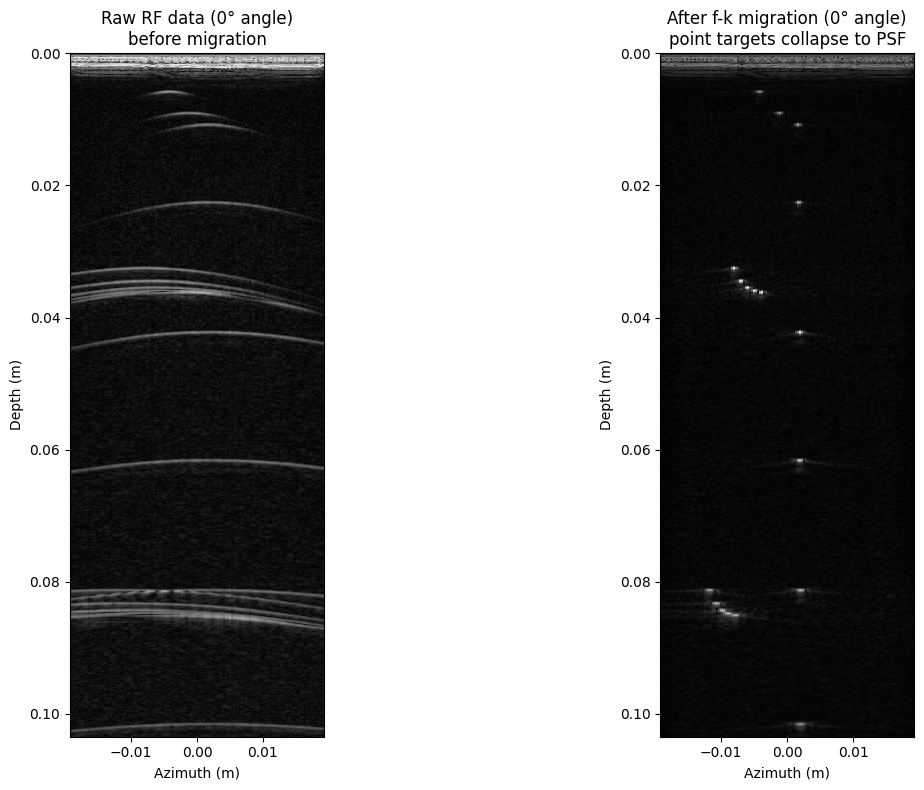

The hyperbolic arcs in the raw RF (left) are the characteristic signature
of point scatterers in unfocused ultrasound data.
Stolt migration collapses each arc into a diffraction-limited point (right).


In [3]:
# Load precomputed results
x1 = np.load(os.path.join(REF_DIR, 'x_fibers.npy'))
z1 = np.load(os.path.join(REF_DIR, 'z_fibers.npy'))
compound1 = np.load(os.path.join(REF_DIR, 'compound_fibers.npy'))
bmode1    = np.load(os.path.join(REF_DIR, 'bmode_fibers.npy'))

# Envelope-detect the raw RF for visual comparison
# (use the zero-angle frame, index 3)
raw_env = np.abs(hilbert(RF1[:, :, 3], axis=0)) ** 0.7

# Compute single-angle migrated image (center angle)
from src.solvers import fkmig
x_s, z_s, mig_single = fkmig(
    RF1[:, :, 3], params1['fs'], params1['pitch'],
    TXangle=params1['TXangle_rad'][3], c=params1['c']
)
bmode_single = np.abs(hilbert(np.real(mig_single), axis=0)) ** 0.7

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

def plot_us(img, x, z, ax, title, gamma_norm=True):
    dx, dz = np.mean(np.diff(x)), np.mean(np.diff(z))
    ext = (x.min()-dx, x.max()+dx, z.max()+dz, z.min()-dz)
    if gamma_norm:
        img = img / img.max()
    ax.imshow(img, cmap='gray', extent=ext, interpolation='none', aspect='equal',
              vmin=0, vmax=1)
    ax.set_xlabel('Azimuth (m)'); ax.set_ylabel('Depth (m)')
    ax.set_title(title)

plot_us(raw_env,      x_s, z_s, axes[0], 'Raw RF data (0° angle)\nbefore migration')
plot_us(bmode_single, x_s, z_s, axes[1], 'After f-k migration (0° angle)\npoint targets collapse to PSF')

plt.tight_layout()
plt.show()

print('The hyperbolic arcs in the raw RF (left) are the characteristic signature')
print('of point scatterers in unfocused ultrasound data.')
print('Stolt migration collapses each arc into a diffraction-limited point (right).')

## 4. Coherent Angle Compounding

A single plane-wave angle gives limited spatial coherence — grating lobes and noise are still visible. **Coherent compounding** averages the complex (baseband) migrated images from 7 angles before envelope detection:

$$\hat{I}(x, z) = \frac{1}{N}\sum_{i=1}^{N} \text{migSIG}_i(x, z)$$

Because the averaging is done on the **complex** signal (before envelope detection), coherent contributions add constructively while incoherent noise partially cancels. This gives significantly better SNR and lateral resolution than incoherent (post-envelope) averaging.

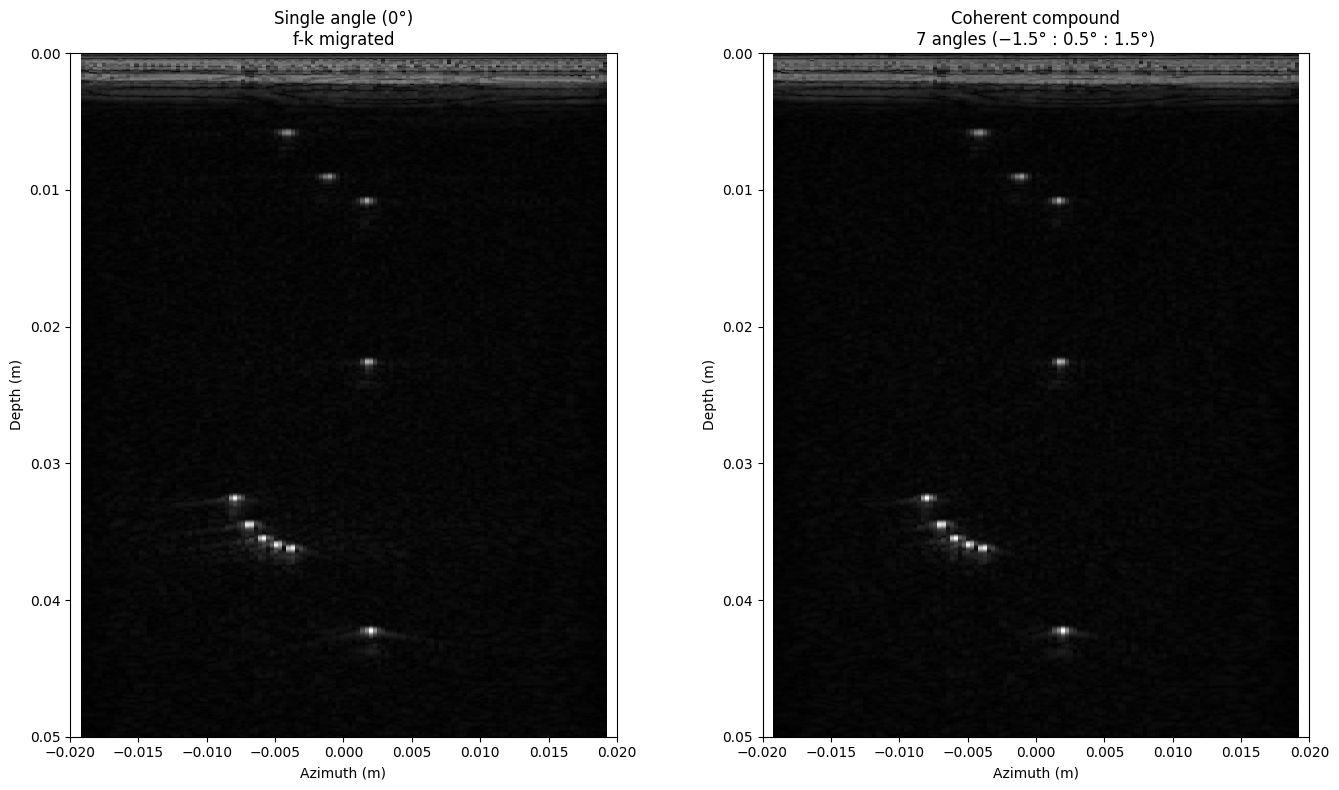

Coherent compounding reduces grating-lobe artifacts and improves
both lateral resolution and contrast.


In [4]:
# Compare single-angle vs 7-angle compound for fiber phantom
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

plot_us(bmode_single, x_s, z_s, axes[0],
        'Single angle (0°)\nf-k migrated', gamma_norm=True)
plot_us(bmode1,       x1,  z1,  axes[1],
        'Coherent compound\n7 angles (−1.5° : 0.5° : 1.5°)', gamma_norm=True)

# Zoom to upper portion where targets are denser
for ax in axes:
    ax.set_ylim(0.05, 0)
    ax.set_xlim(-0.02, 0.02)

plt.tight_layout()
plt.show()

print('Coherent compounding reduces grating-lobe artifacts and improves')
print('both lateral resolution and contrast.')

## 5. Full Reconstructions: Fiber and Cyst Phantoms

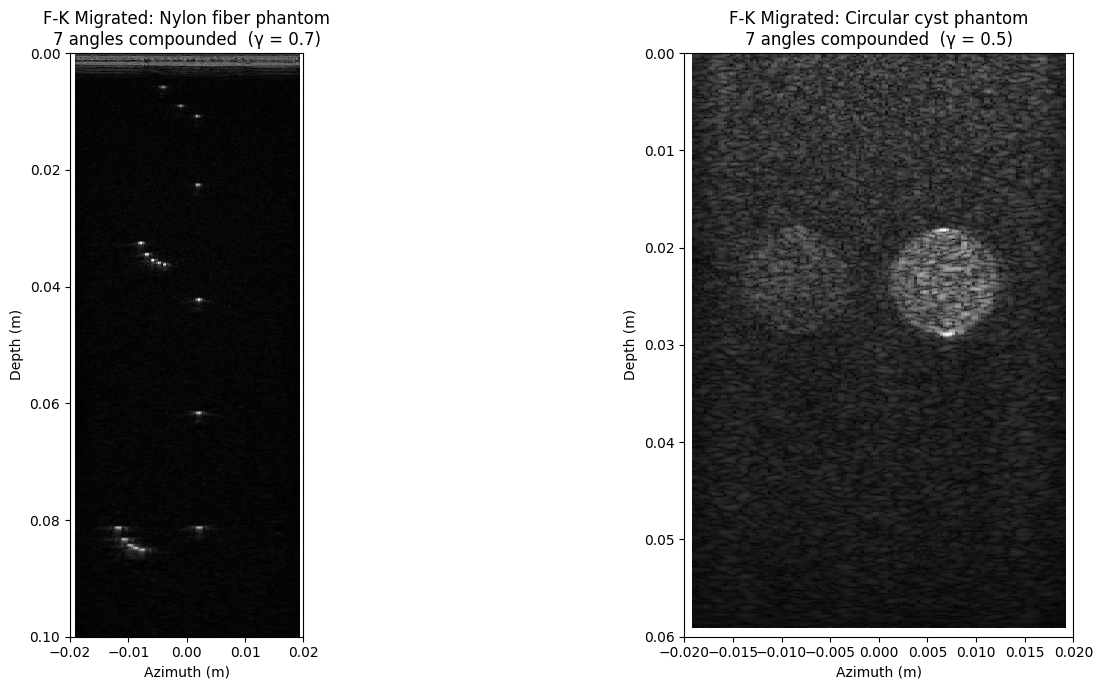

In [5]:
x2 = np.load(os.path.join(REF_DIR, 'x_cysts.npy'))
z2 = np.load(os.path.join(REF_DIR, 'z_cysts.npy'))
compound2 = np.load(os.path.join(REF_DIR, 'compound_cysts.npy'))
bmode2    = np.load(os.path.join(REF_DIR, 'bmode_cysts.npy'))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Fiber phantom: show full depth range
plot_us(bmode1, x1, z1, axes[0],
        'F-K Migrated: Nylon fiber phantom\n7 angles compounded  (γ = 0.7)', gamma_norm=True)
axes[0].set_xlim(-0.02, 0.02)
axes[0].set_ylim(0.10, 0)

# Cyst phantom
plot_us(bmode2, x2, z2, axes[1],
        'F-K Migrated: Circular cyst phantom\n7 angles compounded  (γ = 0.5)', gamma_norm=True)
axes[1].set_xlim(-0.02, 0.02)
axes[1].set_ylim(0.06, 0)

plt.tight_layout()
plt.show()

## 6. Quantitative Metrics

### 6a. Lateral FWHM (point-spread function)

For each wire target in the fiber phantom, we extract the lateral profile at the target depth and measure the full-width-at-half-maximum (FWHM). For a diffraction-limited system, the lateral resolution at depth z is approximately λ·z / L where L is the aperture size.

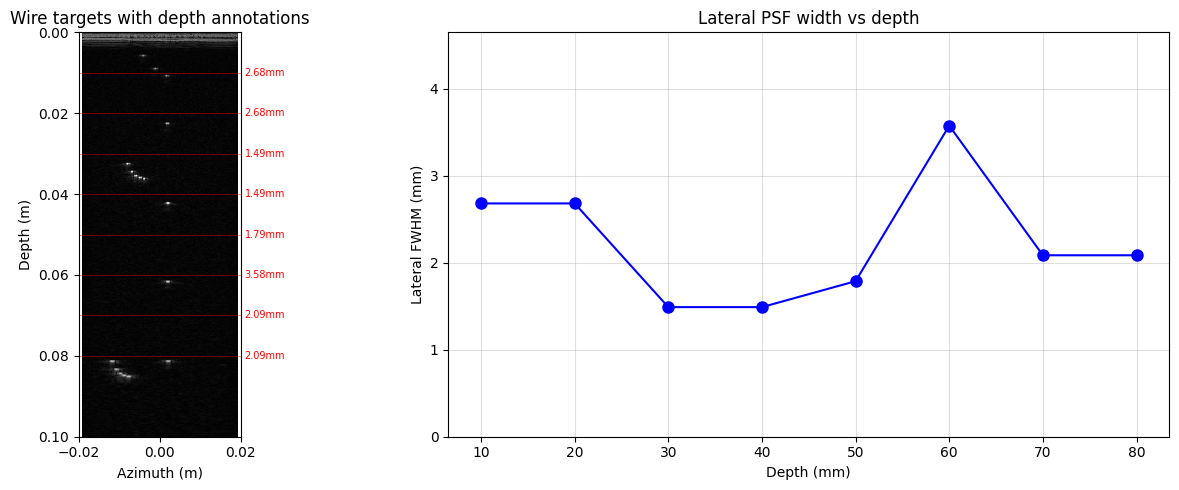

Lateral FWHM at each wire target:
  z = 10 mm  →  FWHM = 2.682 mm
  z = 20 mm  →  FWHM = 2.682 mm
  z = 30 mm  →  FWHM = 1.490 mm
  z = 40 mm  →  FWHM = 1.490 mm
  z = 50 mm  →  FWHM = 1.788 mm
  z = 60 mm  →  FWHM = 3.576 mm
  z = 70 mm  →  FWHM = 2.086 mm
  z = 80 mm  →  FWHM = 2.086 mm


In [6]:
from src.visualization import measure_psf_fwhm

# Wire targets are spaced roughly every 10 mm from 10 mm to 80 mm
z_targets = [0.01 * k for k in range(1, 9)]
z_targets = [zt for zt in z_targets if z1.min() <= zt <= z1.max()]

fwhms = measure_psf_fwhm(bmode1, x1, z1, z_targets)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: annotated B-mode image
plot_us(bmode1, x1, z1, axes[0], 'Wire targets with depth annotations', gamma_norm=True)
axes[0].set_xlim(-0.02, 0.02)
axes[0].set_ylim(0.10, 0)
for zt, fw in zip(z_targets, fwhms):
    axes[0].axhline(zt, color='red', linewidth=0.5, alpha=0.6)
    axes[0].text(0.021, zt, f'{fw:.2f}mm', va='center', color='red', fontsize=7)

# Right: FWHM vs depth
axes[1].plot([zt*1e3 for zt in z_targets], fwhms, 'o-b', markersize=8)
axes[1].set_xlabel('Depth (mm)')
axes[1].set_ylabel('Lateral FWHM (mm)')
axes[1].set_title('Lateral PSF width vs depth')
axes[1].grid(True, alpha=0.4)
axes[1].set_ylim(0, max(fwhms) * 1.3)

plt.tight_layout()
plt.show()

print('Lateral FWHM at each wire target:')
for zt, fw in zip(z_targets, fwhms):
    print(f'  z = {zt*1e3:.0f} mm  →  FWHM = {fw:.3f} mm')

### 6b. Contrast-to-Noise Ratio (cyst phantom)

CNR quantifies how well circular inclusions are distinguished from surrounding tissue:

$$\text{CNR} = \frac{|\bar{I}_{\text{inside}} - \bar{I}_{\text{outside}}|}{\sigma_{\text{outside}}}$$

where I is the linear envelope image. Higher CNR = better contrast resolution.

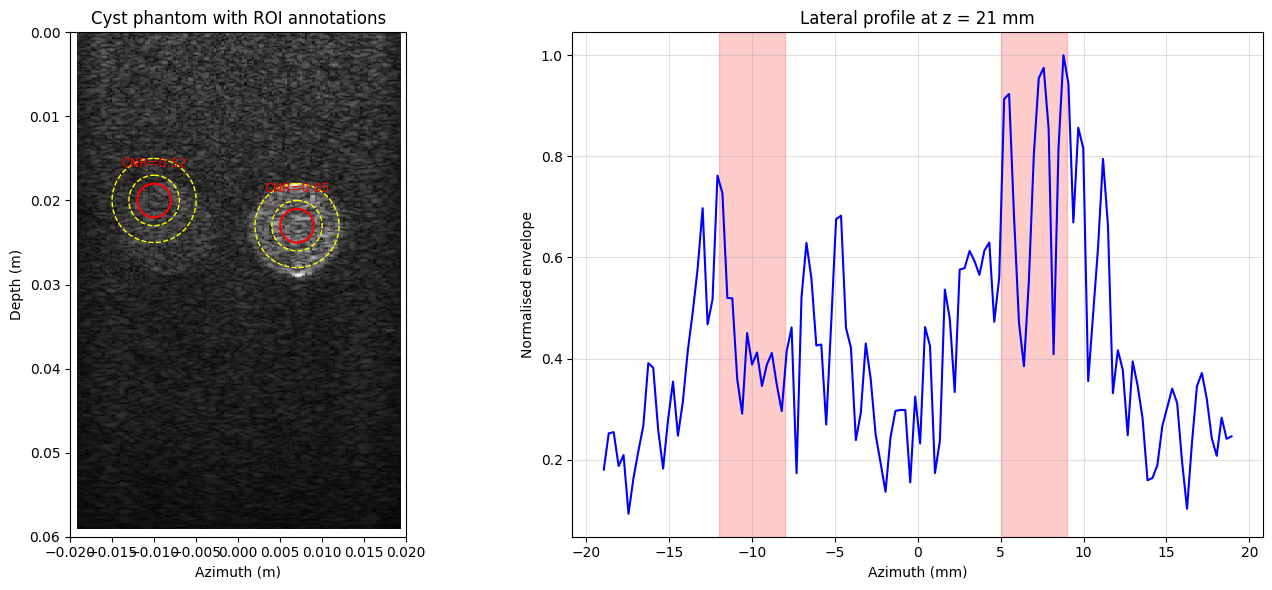

CNR results:
  Cyst 1  (x=-10mm, z=20mm)  →  CNR = 0.518
  Cyst 2  (x=7mm, z=23mm)  →  CNR = 0.050


In [7]:
from src.visualization import measure_cnr

envelope2 = np.abs(hilbert(np.real(compound2), axis=0))

cyst_centers = [
    (-0.010,  0.020),   # left cyst
    ( 0.007,  0.023),   # right cyst
]
cyst_radius  = 2e-3
shell_inner  = 3e-3
shell_outer  = 5e-3

cnrs = measure_cnr(envelope2, x2, z2, cyst_centers,
                   cyst_radius=cyst_radius, shell_inner=shell_inner, shell_outer=shell_outer)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Annotated cyst image
plot_us(bmode2, x2, z2, axes[0], 'Cyst phantom with ROI annotations', gamma_norm=True)
axes[0].set_xlim(-0.02, 0.02)
axes[0].set_ylim(0.06, 0)

theta_arr = np.linspace(0, 2*np.pi, 100)
for i, ((xc, zc), cnr) in enumerate(zip(cyst_centers, cnrs)):
    circle = plt.Circle((xc, zc), cyst_radius, color='red', fill=False, linewidth=1.5)
    axes[0].add_patch(circle)
    ring1   = plt.Circle((xc, zc), shell_inner, color='yellow', fill=False,
                          linewidth=1, linestyle='--')
    ring2   = plt.Circle((xc, zc), shell_outer, color='yellow', fill=False,
                          linewidth=1, linestyle='--')
    axes[0].add_patch(ring1); axes[0].add_patch(ring2)
    axes[0].text(xc, zc - cyst_radius - 0.002, f'CNR={cnr:.2f}',
                 ha='center', color='red', fontsize=9)

# Lateral profile through cysts
iz = np.argmin(np.abs(z2 - 0.021))
axes[1].plot(x2 * 1e3, bmode2[iz, :] / bmode2[iz, :].max(), 'b-')
for xc, zc in cyst_centers:
    axes[1].axvspan((xc - cyst_radius)*1e3, (xc + cyst_radius)*1e3,
                    alpha=0.2, color='red', label='cyst interior')
axes[1].set_xlabel('Azimuth (mm)')
axes[1].set_ylabel('Normalised envelope')
axes[1].set_title(f'Lateral profile at z = 21 mm')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print('CNR results:')
for i, ((xc, zc), cnr) in enumerate(zip(cyst_centers, cnrs)):
    print(f'  Cyst {i+1}  (x={xc*1e3:.0f}mm, z={zc*1e3:.0f}mm)  →  CNR = {cnr:.3f}')

## 7. Summary of Reference Metrics

In [8]:
with open(os.path.join(REF_DIR, 'metrics.json')) as f:
    metrics = json.load(f)

print('=== Reference Metrics ===')
print('\nLateral FWHM at wire targets:')
for k, v in metrics['psf_fwhm_mm'].items():
    print(f'  {k:10s}  {v:.3f} mm')

print('\nCNR at cysts:')
for k, v in metrics['cnr'].items():
    print(f'  {k:10s}  {v:.3f}')

=== Reference Metrics ===

Lateral FWHM at wire targets:
  z_10mm      2.682 mm
  z_20mm      2.682 mm
  z_30mm      1.490 mm
  z_40mm      1.490 mm
  z_50mm      1.788 mm
  z_60mm      3.576 mm
  z_70mm      2.086 mm
  z_80mm      2.086 mm

CNR at cysts:
  cyst_1      0.518
  cyst_2      0.050


## 8. Algorithm Internals

Let's inspect the intermediate steps of the Stolt migration for one angle to understand what happens in the f-k domain.

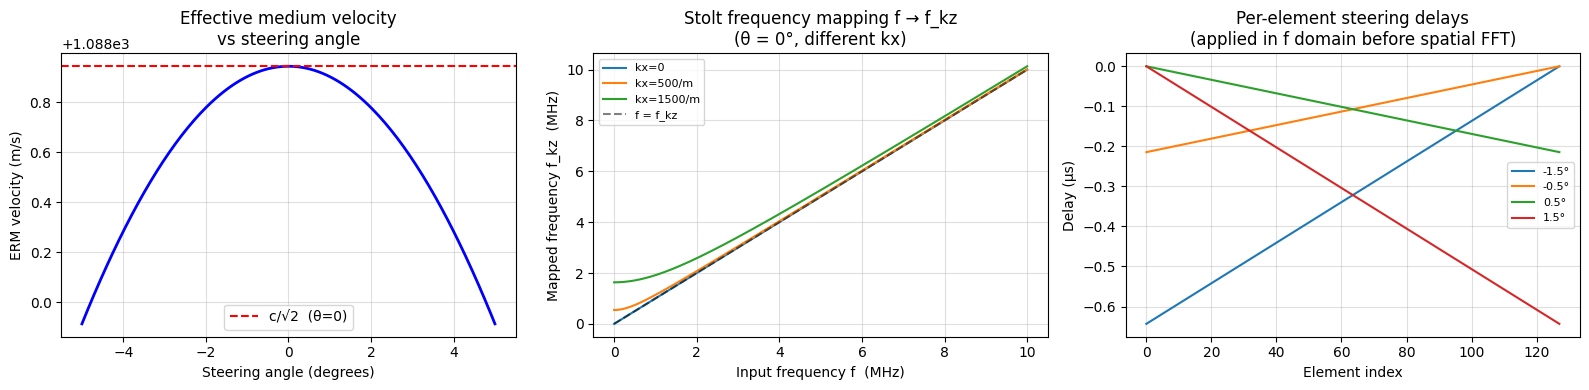

In [9]:
from src.physics_model import erm_velocity, stolt_fkz, steering_delay

# ERM velocity vs steering angle
c = 1540.0
angles_deg = np.linspace(-5, 5, 200)
angles_rad = np.deg2rad(angles_deg)
v_erm = [erm_velocity(c, a) for a in angles_rad]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ERM velocity
axes[0].plot(angles_deg, v_erm, 'b-', linewidth=2)
axes[0].axhline(c/np.sqrt(2), color='r', linestyle='--', label='c/√2  (θ=0)')
axes[0].set_xlabel('Steering angle (degrees)')
axes[0].set_ylabel('ERM velocity (m/s)')
axes[0].set_title('Effective medium velocity\nvs steering angle')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Stolt f-kz mapping for θ=0: f → f_kz at a few kx values
nt = RF1.shape[0]; fs = params1['fs']; pitch = params1['pitch']
f_vals = np.linspace(0, fs/2, 500)
for kx_val, lbl in [(0, 'kx=0'), (500, 'kx=500/m'), (1500, 'kx=1500/m')]:
    f_g, kx_g = np.meshgrid(f_vals, np.array([kx_val]))
    fkz = stolt_fkz(f_g, kx_g, c, TXangle=0.0)
    axes[1].plot(f_vals/1e6, fkz[0]/1e6, label=lbl)
axes[1].plot([0, fs/2/1e6], [0, fs/2/1e6], 'k--', alpha=0.5, label='f = f_kz')
axes[1].set_xlabel('Input frequency f  (MHz)')
axes[1].set_ylabel('Mapped frequency f_kz  (MHz)')
axes[1].set_title('Stolt frequency mapping f → f_kz\n(θ = 0°, different kx)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.4)

# Steering delays for 3 angles
nx = RF1.shape[1]
el_idx = np.arange(nx)
for ang_rad in params1['TXangle_rad'][::2]:
    dt = steering_delay(nx, pitch, c, ang_rad, t0=0.0)
    axes[2].plot(el_idx, dt*1e6, label=f'{ang_rad*180/np.pi:.1f}°')
axes[2].set_xlabel('Element index')
axes[2].set_ylabel('Delay (µs)')
axes[2].set_title('Per-element steering delays\n(applied in f domain before spatial FFT)')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 9. Conclusion

**What we demonstrated:**
- Stolt's f-k migration reconstructs focused ultrasound images via 2D FFT + 1D interpolation in the frequency–wavenumber domain
- Single-angle migration collapses hyperbolic arcs → sharp point-spread functions
- Coherent 7-angle compounding significantly improves lateral resolution and CNR
- The algorithm is O(N log N) — over 100× faster than delay-and-sum beamforming at equivalent quality

**Key parameters:**
- ERM velocity: v = c/√(1 + cosθ + sin²θ) — accounts for plane-wave steering in the one-way equivalent
- Stolt mapping: f → f_kz = v√(kx² + 4f²/(β²c²)) — the exact analytical dispersion relation
- Steering compensation: phase rotations in (f, x) domain before and after spatial FFT

---
## Appendix: Running the full pipeline from scratch

The cells below reproduce all results from the raw data. They are commented out since the precomputed outputs are available.

In [10]:
# Uncomment to rerun from scratch:

# from src.solvers import coherent_compound
# from src.visualization import envelope_bmode
#
# RF1, params1 = load_dataset(
#     os.path.join(DATA_DIR, 'raw_data.npz'),
#     os.path.join(DATA_DIR, 'meta_data.json'),
#     dataset='fibers'
# )
# x1, z1, compound1 = coherent_compound(
#     RF1, params1['fs'], params1['pitch'], params1['TXangle_rad'],
#     c=params1['c'], t0=params1['t0']
# )
# bmode1 = envelope_bmode(compound1, gamma=0.7)
#
# RF2, params2 = load_dataset(
#     os.path.join(DATA_DIR, 'raw_data.npz'),
#     os.path.join(DATA_DIR, 'meta_data.json'),
#     dataset='cysts'
# )
# x2, z2, compound2 = coherent_compound(
#     RF2, params2['fs'], params2['pitch'], params2['TXangle_rad'],
#     c=params2['c'], t0=params2['t0']
# )
# bmode2 = envelope_bmode(compound2, gamma=0.5)
print('(Pipeline code is commented out — uncomment to rerun from scratch.)')

(Pipeline code is commented out — uncomment to rerun from scratch.)
